In [1]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Problem 1

For each of the following systems, do a center manifold reduction at the origin (with the bifurcation occurring at $\epsilon=0$ and use the equation for the center manifold dynamics to classify the bifurcation type.

## A 

suppose $x$ is on $S$ (the circle, 0 to $2\pi$) and $v\in\mathbb{R}$.
$$\begin{align}\frac{dx}{dt} =&\; -x + \epsilon v + v^2\\
\frac{dv}{dt} =&\; - \sin x\end{align}$$

---

### Define symbolic variables

In [2]:
x, v, eps = smp.symbols(r'x v \epsilon')

dx = -x + eps*v + v**2
dx

\epsilon*v + v**2 - x

In [3]:
dv = -smp.sin(x)
dv

-sin(x)

### Jacob

In [4]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,v)],
                  [smp.diff(dv,x),smp.diff(dv,v)]])

Jac

Matrix([
[     -1, \epsilon + 2*v],
[-cos(x),              0]])

In [5]:
J0 = Jac.subs([[x,0],[v,0],[eps,0]])
J0

Matrix([
[-1, 0],
[-1, 0]])

In [6]:
J0.eigenvals()

{-1: 1, 0: 1}

Using $\dot v$ as the function associated with the center manifold, $x$ will be replaced by $h(v,\epsilon)$.

$$\begin{align}\dot v =&  (-\sin x) \\ 
\dot x =& -x + (\epsilon v + v^2)\end{align}$$

$$\begin{cases}A = 0\\
g_1 = -sin(x)\\
B = -1\\
g_2 = \epsilon v + v^2\end{cases}$$

Which all is plugged into the equation

$$\mathcal{N} = 0 = Dh(Av + g_1) -Bh - g_2$$

Now $h(v,\epsilon)$ needs to be designed such that it satisfis $h(0)=Dh(0)=0$. 

$$h = av^2 + bv\epsilon + c \epsilon^2$$

For this problem, $\sin x$ will be replaced by the taylor approximation, which should be sufficient since the problem is approximating the origin.

$$sin(x) \approx -x + \frac{x^3}{3!} - \frac{x^5}{5!} + \frac{x^7}{7!}$$

### Center Manifold

In [7]:
a, b, c = smp.symbols(r'a b c')

In [8]:
taylor_sin = x - x**3/(3*2) #+ x**5/(5*4*3*2) - x**7/(7*6*5*4*3*2)
# dv = -taylor_sin

In [9]:
A = dv.coeff(x,0).coeff(v,1).coeff(eps,0)
B = dx.coeff(x,1).coeff(v,0).coeff(eps,0)

h = a*v**2 + b*v*eps + c*eps**2

g1 = dv - A*v
g2 = dx - B*x



dh = smp.diff(h,v)

N = (dh*(A*v + g1)-B*h - g2).subs(x,h)
N

\epsilon**2*c + \epsilon*b*v - \epsilon*v + a*v**2 - v**2 - (\epsilon*b + 2*a*v)*sin(\epsilon**2*c + \epsilon*b*v + a*v**2)

`.expand()` just *expands* all the multiplication. It is a necessary step, so that **sympy** can collect terms.

In [10]:
N = N.expand()

`.coeff(eps,0)` collects all the *coefficients* in `N` with a `eps` power of `0`. Then `.coeff(v,1)` further filters the collected terms for powers `v` order `1`

In [11]:
N.coeff(eps,0).coeff(v,1)

0

In [12]:
N.coeff(eps,1).coeff(v,0)

0

In [13]:
eps_v = N.coeff(eps,1).coeff(v,1)
eps_v

b - 1

In [14]:
eps_pow2 = N.coeff(eps,2).coeff(v,0)
eps_pow2

c

In [15]:
v_pow2 = N.coeff(eps,0).coeff(v,2)
v_pow2

a - 1

`.solve([functions],[variables])` finds the solutions for the `variables` given the `functions`.

In [16]:
abc = smp.solve([eps_v,eps_pow2,v_pow2],[a,b,c])
abc

{b: 1, c: 0, a: 1}

`.subs()` *substitutes* symbolic variables of an existing equation; the coefficients of `h` are being replaced by those solved for in `abc`.

In [17]:
h_sub = h.subs([[a,abc[a]],
                [b,abc[b]],
                [c,abc[c]]])
h_sub

\epsilon*v + v**2

Now making the substitution $x=h(v,\epsilon)$ in $\dot v = -\sin(x)$

In [18]:
dv_sub = -taylor_sin.subs(x,h_sub)
dv_sub

-\epsilon*v - v**2 + (\epsilon*v + v**2)**3/6

`.lambdify()` converts a symbolic variable into a numerical function.

In [19]:
dv_func = smp.lambdify([eps,v],dv_sub)
h_func = smp.lambdify([eps,v],h_sub)
def de(e,v):
    return 0 

### Simulation

In [20]:
fntsize = [10,12,14]

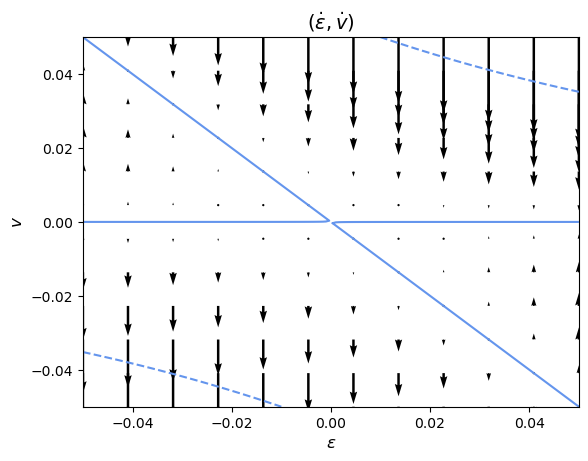

In [21]:
elim = [-0.05,0.05]
vlim = [-0.05,0.05]

ec = np.linspace(elim[0],elim[1],150)
vc = np.linspace(vlim[0],vlim[1],150)

eq = np.linspace(elim[0],elim[1],12)
vq = np.linspace(vlim[0],vlim[1],12)

eC, vC = np.meshgrid(ec,vc)
eQ, vQ = np.meshgrid(eq,vq)

plt.contour(eC,vC,dv_func(eC,vC),levels=1,colors='cornflowerblue')
# plt.colorbar()
plt.quiver(eQ,vQ,de(eQ,vQ),dv_func(eQ,vQ))

plt.ylabel(r'$v$',fontsize=fntsize[1])
plt.xlabel(r'$\epsilon$',fontsize=fntsize[1])
plt.title(r'$(\dot\epsilon,\dot v)$',fontsize=fntsize[2])

plt.show()

### Discussion

This looks to be a trans critical bifurcation with $v=0$ being unstable when $\epsilon<0$ and stable when $\epsilon>0$. In the above graph, the blue line is generated by a contour function, and in this case correlates to where the function $\dot v(\epsilon,v) = 0$

## B 

suppose $x,y\in\mathbb{R}$, and
$$\begin{align}\frac{dx}{dt} =&\; \frac{x}{2} + y + x^2y\\
\frac{dy}{dt} =&\; x + 2y + \epsilon y + y^2\end{align}$$

---

### Define system

In [22]:
x, y, eps, A, B, g1, g2, u, v = smp.symbols(r'x y \epsilon A B g_1 g_2 u v')

dx = x/2 + y + x**2*y
dx

x**2*y + x/2 + y

In [23]:
dy = x + 2*y + eps*y + y**2
dy

\epsilon*y + x + y**2 + 2*y

### Ya-cob-ian

In [24]:
Jac = smp.Matrix([[smp.diff(dx,x),smp.diff(dx,y)],
                  [smp.diff(dy,x),smp.diff(dy,y)]])

Jac

Matrix([
[2*x*y + 1/2,           x**2 + 1],
[          1, \epsilon + 2*y + 2]])

In [25]:
J0 = Jac.subs([[x,0],[y,0]])
J0.subs(eps,0)

Matrix([
[1/2, 1],
[  1, 2]])

In [26]:
J0 = J0.subs(eps,0)
smp.Matrix.eigenvals(J0)

{5/2: 1, 0: 1}

In [27]:
J0 = J0.subs(eps,0)
v1 = smp.Matrix.eigenvects(J0)[0][2][0]
v1

Matrix([
[-2],
[ 1]])

In [28]:
v2 = smp.Matrix.eigenvects(J0)[1][2][0]
v2

Matrix([
[1/2],
[  1]])

### Transform 

Transforming to the eigenbasis $w\to$ center, and $u\to$ unstable, by using the matrix $P\to$ coulomb vector of eigenvectors.

$$\begin{bmatrix}x\\ y\end{bmatrix} = 
\begin{bmatrix}-2 & 1/2\\ 1 & 1\end{bmatrix} 
\begin{bmatrix}w\\ u\end{bmatrix}$$

Which gives the substitutions for $x$ and $y$ (called `trans` in the code below), in the system

$$\begin{bmatrix}\dot w\\ \dot u\end{bmatrix} = P^{-1} 
\begin{bmatrix}\dot x\\ \dot y\end{bmatrix}$$

Defining the needed symbolic variables

In [29]:
w, u = smp.symbols('w u')
wu = smp.Matrix([w,u])
xy = smp.Matrix([x,y])

Computing $P$ and $P^{-1}$

In [30]:
P = smp.Matrix([[-2,1],[1/2,1]]).T
Pinv = P.inv()

First matrix equation above

In [31]:
trans = P@wu
trans

Matrix([
[0.5*u - 2*w],
[      u + w]])

Second matrix equation above

In [32]:
dwu = (Pinv@smp.Matrix([dx,dy]))
dwu

Matrix([
[                0.2*\epsilon*y - 0.4*x**2*y + 0.2*y**2],
[0.8*\epsilon*y + 0.4*x**2*y + 1.0*x + 0.8*y**2 + 2.0*y]])

Substituting first equation into second, and separating into individual function

In [33]:
dwu = dwu.subs([[x,trans[0]],[y,trans[1]]])
dw = dwu[0].expand()
du = dwu[1].expand()

In [34]:
dw

0.2*\epsilon*u + 0.2*\epsilon*w - 0.1*u**3 + 0.7*u**2*w + 0.2*u**2 - 0.8*u*w**2 + 0.4*u*w - 1.6*w**3 + 0.2*w**2

In [35]:
dw.coeff(w,1).coeff(u,0).coeff(eps,0)

0

In [36]:
du.coeff(w,0).coeff(u,1).coeff(eps,0)

2.50000000000000

### $\mathcal{N}$

Similar to **problem 1.a** the $h$ and $\mathcal{N}$ is built and solved as 

$$\mathcal{N} = 0 = Dh(Ay + g_1) -Bh - g_2$$

$$h = a w^2 + b w\epsilon + c \epsilon^2$$

and is solved by coefficient matching, so that $h(0)=Dh(0)=0$. In this case the transformation to the eigenbasis makes the equations too messy to expand out fully. The below code solution is outlined as follows

1. **Given**: the system in eigenbasis $[\dot w,\dot u]^T$
2. $A$: is the terms in $\dot w$ linear in $w$
    * solved by layering `.coeff()`
3. $B$: is the terms in $\dot u$ linear in $u$
    * solved by layering `.coeff()`
4. $g_1$: is the rest of the terms in $\dot w$
5. $g_2$: is the rest of the terms in $\dot u$
6. h: is built and solved in a similar manner to **problem 1.a**

In [37]:
A = dw.coeff(w,1).coeff(u,0).coeff(eps,0)
B = du.coeff(w,0).coeff(u,1).coeff(eps,0)

g1 = dw - A*w
g2 = du - B*u

In [38]:
h =  a*w**2 + b*w*eps + c*eps**2
dh = smp.diff(h,w)
N = (dh*(A*w + g1)-B*h - g2).subs(u,h)
N

-2.5*\epsilon**2*c - 2.5*\epsilon*b*w - 0.8*\epsilon*w - 0.8*\epsilon*(\epsilon**2*c + \epsilon*b*w + a*w**2) - 2.5*a*w**2 - 1.6*w**3 - 0.8*w**2*(\epsilon**2*c + \epsilon*b*w + a*w**2) - 0.8*w**2 + 0.7*w*(\epsilon**2*c + \epsilon*b*w + a*w**2)**2 - 1.6*w*(\epsilon**2*c + \epsilon*b*w + a*w**2) + (\epsilon*b + 2*a*w)*(0.2*\epsilon*w + 0.2*\epsilon*(\epsilon**2*c + \epsilon*b*w + a*w**2) - 1.6*w**3 - 0.8*w**2*(\epsilon**2*c + \epsilon*b*w + a*w**2) + 0.2*w**2 + 0.7*w*(\epsilon**2*c + \epsilon*b*w + a*w**2)**2 + 0.4*w*(\epsilon**2*c + \epsilon*b*w + a*w**2) - 0.1*(\epsilon**2*c + \epsilon*b*w + a*w**2)**3 + 0.2*(\epsilon**2*c + \epsilon*b*w + a*w**2)**2) - 0.1*(\epsilon**2*c + \epsilon*b*w + a*w**2)**3 - 0.8*(\epsilon**2*c + \epsilon*b*w + a*w**2)**2

In [39]:
N = N.expand()

In [40]:
N.coeff(w,0).coeff(eps,1)

0

In [41]:
N.coeff(w,1).coeff(eps,0)

0

In [42]:
w_eps = N.coeff(w,1).coeff(eps,1)
w_eps

-2.5*b - 0.8

In [43]:
w_pow2 = N.coeff(w,2).coeff(eps,0)
w_pow2

-2.5*a - 0.8

In [44]:
eps_pow2 = N.coeff(w,0).coeff(eps,2)
eps_pow2

-2.5*c

In [45]:
abc = smp.solve([w_pow2,w_eps,eps_pow2],[a,b,c])
abc

{a: -0.320000000000000, b: -0.320000000000000, c: 0.0}

In [46]:
h_sub = h.subs([[a,abc[a]],[b,abc[b]],[c,abc[c]]])
h_sub

-0.32*\epsilon*w - 0.32*w**2

In [47]:
dw_sub = dw.subs(u,h_sub)
dw_sub

0.2*\epsilon*w + 0.2*\epsilon*(-0.32*\epsilon*w - 0.32*w**2) - 1.6*w**3 - 0.8*w**2*(-0.32*\epsilon*w - 0.32*w**2) + 0.2*w**2 + 0.07168*w*(-\epsilon*w - w**2)**2 + 0.4*w*(-0.32*\epsilon*w - 0.32*w**2) - 0.0032768*(-\epsilon*w - w**2)**3 + 0.02048*(-\epsilon*w - w**2)**2

In [48]:
dw_func = smp.lambdify([eps,w],dw_sub)
h_func = smp.lambdify([eps,w],h_sub)
def de(e,w):
    return 0

### Sim

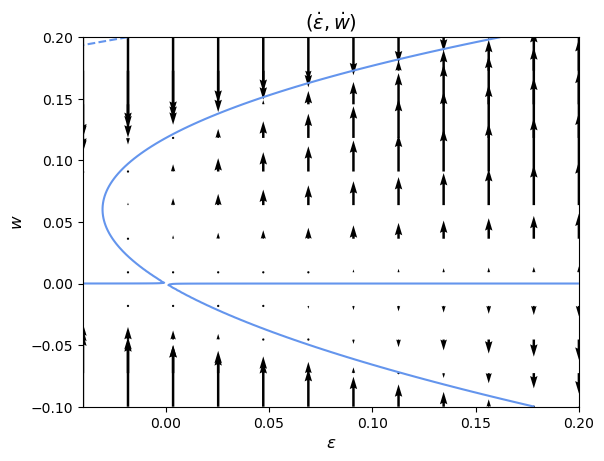

In [49]:
elim = [-0.04,0.2]
wlim = [-0.1,0.2]

ec = np.linspace(elim[0],elim[1],150)
wc = np.linspace(wlim[0],wlim[1],150)

eq = np.linspace(elim[0],elim[1],12)
wq = np.linspace(wlim[0],wlim[1],12)

eC, wC = np.meshgrid(ec,wc)
eQ, wQ = np.meshgrid(eq,wq)

plt.contour(eC,wC,dw_func(eC,wC),levels=1,colors='cornflowerblue')
# plt.colorbar()
plt.quiver(eQ,wQ,de(eQ,wQ),dw_func(eQ,wQ))

plt.ylabel(r'$w$',fontsize=fntsize[1])
plt.xlabel(r'$\epsilon$',fontsize=fntsize[1])
plt.title(r'$(\dot\epsilon,\dot w)$',fontsize=fntsize[2])

plt.show()

### Discussion

Similar to **problem 1.a** the blue line is from a contour function, in this case it is the line where $\dot w(\epsilon,w)=0$. As the neighborhood around the origin gets smallar, the nonlinearity of the plot becomes approximatly linear and is representative of a transcritical bifurcation with $w$ being stable when $\epsilon<0$ and unstable when $\epsilon>0$. 

# Problem 2

Compute the normal form for a map in the neighborhood of a fixed point having the linear part 

$$\begin{pmatrix}1&1\\0&1\end{pmatrix}$$

through second order terms. **Compare** your results to Ex 19.1.2, which has linear part.

$$\begin{pmatrix}0&1\\0&0\end{pmatrix}$$


---

$$L_J^k(h_k(y)) \equiv -(Dh_k(y)Jy-Jh_k(y))$$

In [50]:
x, y, J = smp.symbols('x y J')

h1 = smp.Matrix([[x**2],
                 [0]])
h2 = smp.Matrix([[x*y],
                 [0]])
h3 = smp.Matrix([[y**2],
                 [0]])
h4 = smp.Matrix([[0],
                 [x**2]])
h5 = smp.Matrix([[0],
                 [x*y]])
h6 = smp.Matrix([[0],
                 [y**2]])

H = [h1,h2,h3,h4,h5,h6]

J = smp.Matrix([[1,1],
                [0,1]])

v = smp.Matrix([[x],
                [y]])

In [51]:
J@v

Matrix([
[x + y],
[    y]])

In [52]:
h = H[0]

L1 = J@h - h.subs(x,x+y)
# L1

In [53]:
h = H[1]

L2 = J@h - h.subs(x,x+y)
# L2

In [54]:
h = H[2]

L3 = J@h - h.subs(x,x+y)
# L3

In [55]:
h = H[3]

L4 = J@h - h.subs(x,x+y)
# L4

In [56]:
h = H[4]

L5 = J@h - h.subs(x,x+y)
# L5

In [57]:
h = H[5]

L6 = J@h - h.subs(x,x+y)
# L6

In [58]:
L1.expand()

Matrix([
[-2*x*y - y**2],
[            0]])

In [59]:
L2.expand()

Matrix([
[-y**2],
[    0]])

In [60]:
L3

Matrix([
[0],
[0]])

In [61]:
L4.expand()

Matrix([
[         x**2],
[-2*x*y - y**2]])

In [62]:
L5.expand()

Matrix([
[  x*y],
[-y**2]])

In [63]:
L6

Matrix([
[y**2],
[   0]])

In [64]:
G = smp.Matrix([[0,-2,-1, 0,0,0],
               [0,0,-1,  0,0,0],
               [0,0,0,   0,0,0],
               [1,0,0,   0,-2,-1],
               [0,1,0,    0,0,-1],
               [0,0,1,    0,0,0]]).T
G

Matrix([
[ 0,  0, 0,  1,  0, 0],
[-2,  0, 0,  0,  1, 0],
[-1, -1, 0,  0,  0, 1],
[ 0,  0, 0,  0,  0, 0],
[ 0,  0, 0, -2,  0, 0],
[ 0,  0, 0, -1, -1, 0]])

In [65]:
G.left_eigenvects()

[(0, 6, [Matrix([[0, 0, 0, 1, 0, 0]]), Matrix([[2, 0, 0, 0, 1, 0]])])]

$$\begin{align}\dot x =&\; (x+y) + 2a_2x^2 +\mathcal{O}(3)\\
\dot y =&\; (y) + a_1x^2 + a_2xy +\mathcal{O}(3) \end{align}$$ 

## EX 19.1.2

In [66]:
G_ex = smp.Matrix([[0,-2,0,0,0,0],
               [0,0,-1,0,0,0],
               [0,0,0,0,0,0],
               [1,0,0,0,-2,0],
               [0,1,0,0,0,-1],
               [0,0,1,0,0,0]]).T
G_ex

Matrix([
[ 0,  0, 0,  1,  0, 0],
[-2,  0, 0,  0,  1, 0],
[ 0, -1, 0,  0,  0, 1],
[ 0,  0, 0,  0,  0, 0],
[ 0,  0, 0, -2,  0, 0],
[ 0,  0, 0,  0, -1, 0]])

In [67]:
G_ex.eigenvects()

[(0,
  6,
  [Matrix([
   [0],
   [0],
   [1],
   [0],
   [0],
   [0]]),
   Matrix([
   [0],
   [1],
   [0],
   [0],
   [0],
   [1]])])]

In [68]:
G_ex.eigenvects()[0][2][0].T

Matrix([[0, 0, 1, 0, 0, 0]])

In [69]:
G_ex.eigenvects()[0][2][1].T

Matrix([[0, 1, 0, 0, 0, 1]])

$$\begin{align}\dot x =&\; y + a_1x^2 +\mathcal{O}(3)\\
\dot y =&\; 0 + a_2xy + a_3x^2 +\mathcal{O}(3) \end{align}$$ 